In [1]:
# code to collect sign data for 3 different signs 
import os
import cv2

DATA_DIR = "./Sign_Data/"
if not os.path.exists(DATA_DIR):
    os.mkdir(DATA_DIR)

number_of_classes = 3
dataset_size = 100

cap = cv2.VideoCapture(0)
for i in range(number_of_classes):
    if not os.path.exists(os.path.join(DATA_DIR,str(i))):
        os.mkdir(os.path.join(DATA_DIR,str(i)))

    print(f"Collecting the data for class {i}")
    done = False
    while True:
        ret,frame = cap.read()
        cv2.putText(frame,"Ready? press 'Q' !",(100,50),cv2.FONT_HERSHEY_SIMPLEX,1.3,(0,255,0),3,cv2.LINE_AA)
        cv2.imshow("frame",frame)
        if cv2.waitKey(25) == ord('q'):
            break
    counter = 0
    while counter < dataset_size:
        ret,frame = cap.read()
        cv2.imshow("frame",frame)
        cv2.waitKey(25)
        cv2.imwrite(os.path.join(DATA_DIR,str(i),f"{counter}.jpg"),frame)
        counter += 1

cap.release()
cv2.destroyAllWindows()

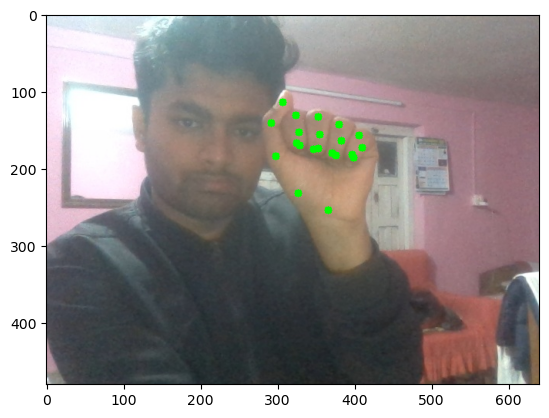

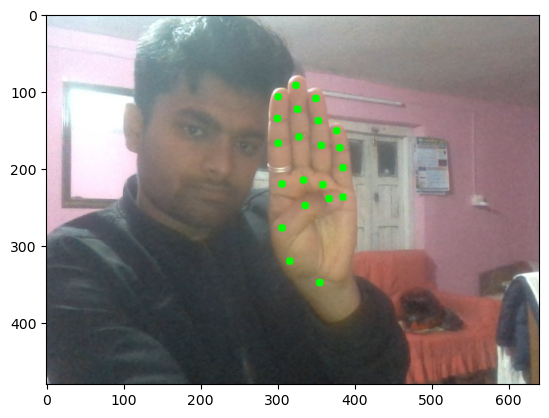

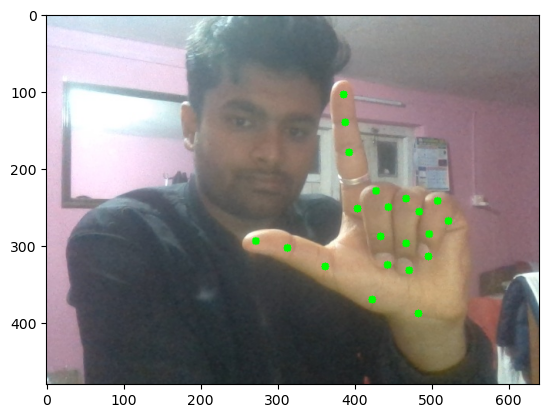

In [4]:
# lets create a dataset
import os
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode
Image = mp.Image
ImageFormat = mp.ImageFormat

MODEL_PATH = "hand_landmarker.task"
DATA_DIR = "../../Sign_Data/"

options = HandLandmarkerOptions(base_options=BaseOptions(model_asset_path=MODEL_PATH),running_mode=VisionRunningMode.IMAGE)

landmarker = HandLandmarker.create_from_options(options)

for dir_ in os.listdir(DATA_DIR):
    for img_path in os.listdir(os.path.join(DATA_DIR,dir_))[:1]:
        img = cv2.imread(os.path.join(DATA_DIR,dir_,img_path))
        img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        mp_img = Image(image_format=ImageFormat.SRGB,data=img_rgb)
        result = landmarker.detect(mp_img)
        h,w,_ = img.shape
        if result.hand_landmarks:
            for hand in result.hand_landmarks:
                for lm in hand:
                    x = int(lm.x * w)
                    y = int(lm.y * h)
                    cv2.circle(img_rgb,(x,y),5,(0,255,0),-1)

        plt.figure()
        plt.imshow(img_rgb)


In [5]:
# lets create a dataset
import os
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import pickle

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode
Image = mp.Image
ImageFormat = mp.ImageFormat

MODEL_PATH = "hand_landmarker.task"
DATA_DIR = "../../Sign_Data/"
data = []
labels = []

options = HandLandmarkerOptions(base_options=BaseOptions(model_asset_path=MODEL_PATH),running_mode=VisionRunningMode.IMAGE)

landmarker = HandLandmarker.create_from_options(options)

for dir_ in os.listdir(DATA_DIR):
    for img_path in os.listdir(os.path.join(DATA_DIR,dir_)):
        data_aux = []
        img = cv2.imread(os.path.join(DATA_DIR,dir_,img_path))
        img_rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        mp_img = Image(image_format=ImageFormat.SRGB,data=img_rgb)
        result = landmarker.detect(mp_img)
        if result.hand_landmarks:
            for hand in result.hand_landmarks:
                for lm in hand:
                    x = lm.x
                    y = lm.y
                    data_aux.append(x)
                    data_aux.append(y)
            data.append(data_aux)
            labels.append(dir_)

f = open("sign_data.pickle",'wb')
pickle.dump({'data':data,'labels':labels},f)
f.close()
                    


In [5]:
# Training the model
import pickle
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data_dict = pickle.load(open("sign_data.pickle","rb"))
data = np.asarray(data_dict['data'])
labels = np.asarray(data_dict['labels'])

# lets split the data into train ans test split
x_train,x_test,y_train,y_test = train_test_split(data,labels,test_size=0.2,shuffle=True,stratify=labels)

model = RandomForestClassifier()

model.fit(x_train,y_train)

y_preds = model.predict(x_test)

score = accuracy_score(y_test,y_preds)

print(f"The accuracy score is {score*100:.2f}%")

f = open("model.pkl",'wb')
pickle.dump({'model':model},f)
f.close()

The accuracy score is 100.00%


In [8]:
import cv2
import mediapipe as mp
import pickle
model_dict = pickle.load(open("model.pkl","rb"))
model = model_dict["model"]

MODEL_PATH = "hand_landmarker.task"

BaseOptions = mp.tasks.BaseOptions
HandLandmarker = mp.tasks.vision.HandLandmarker
HandLandmarkerOptions = mp.tasks.vision.HandLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode
Image = mp.Image
ImageFormat = mp.ImageFormat

options = HandLandmarkerOptions(base_options=BaseOptions(model_asset_path=MODEL_PATH),running_mode=VisionRunningMode.VIDEO)

landmarker = HandLandmarker.create_from_options(options)


cap = cv2.VideoCapture(0)
labels_dict = {0:'A',1:"B",2:"L"}

while True:
    data_aux = []
    x_ = []
    y_ = []
    ret,frame = cap.read()
    h,w,_  = frame.shape
    rgb_frame = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)
    mp_img =Image(image_format=ImageFormat.SRGB,data=rgb_frame)
    timestamp = int(cv2.getTickCount() / cv2.getTickFrequency() * 1000)
    result = landmarker.detect_for_video(mp_img,timestamp)
    if result.hand_landmarks:
        for hand in result.hand_landmarks:
            for lm in hand:
                x = lm.x
                y = lm.y
                data_aux.append(x)
                data_aux.append(y)
                x_.append(x)
                y_.append(y)
        x1 = int(min(x_) * w) - 10
        y1 = int(min(y_) * h) - 10
        x2 = int(max(x_) * w) - 10
        y2 = int(max(y_) * h) - 10

        predeictions = model.predict([np.asarray(data_aux)])
        predicted_char = labels_dict[int(predeictions[0])]

        cv2.rectangle(frame,(x1,y1),(x2,y2),(0,0,0),4)
        cv2.putText(frame,predicted_char,(x1,y1-10),cv2.FONT_HERSHEY_SIMPLEX,1.3,(0,0,0),3,cv2.LINE_AA)
    cv2.imshow("frame",frame)
    if cv2.waitKey(1) & 0xff == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()
        